In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("/content/Mall_Customers.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df = df.drop_duplicates()

df = df.dropna()

print("Dataset after preprocessing:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

Dataset after preprocessing:
Rows: 200
Columns: 5

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print("Selected Features:")
display(X.head())

Selected Features:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features standardized successfully!")
print(X_scaled[:5])

Features standardized successfully!
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


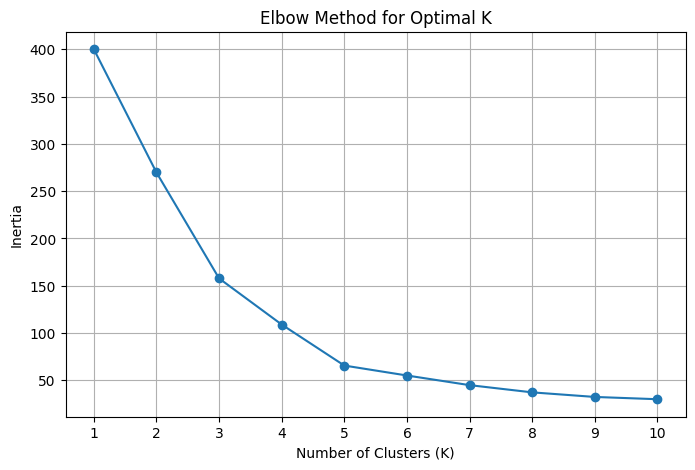

In [7]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

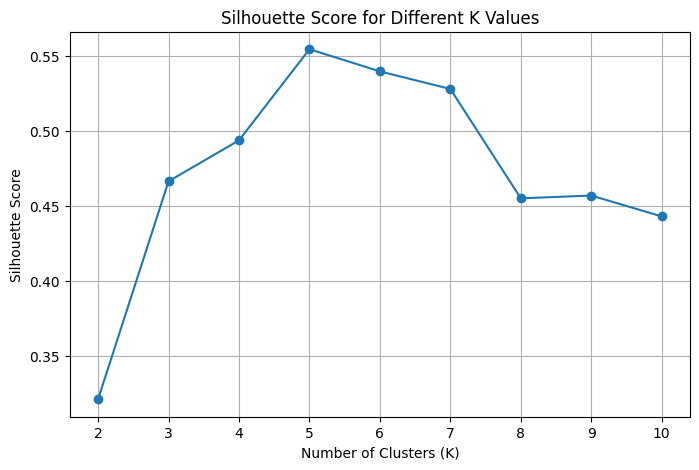

Best K according to Silhouette Score: 5
Highest Silhouette Score: 0.5546571631111091


In [8]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

best_k = range(2, 11)[np.argmax(silhouette_scores)]

print("Best K according to Silhouette Score:", best_k)
print("Highest Silhouette Score:", max(silhouette_scores))

In [9]:
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")
print("\nCluster counts:")
print(df['Cluster'].value_counts().sort_index())

K-Means clustering completed!

Cluster counts:
Cluster
0    12
1    43
2    29
3    10
4    15
5    10
6    22
7    13
8    40
9     6
Name: count, dtype: int64


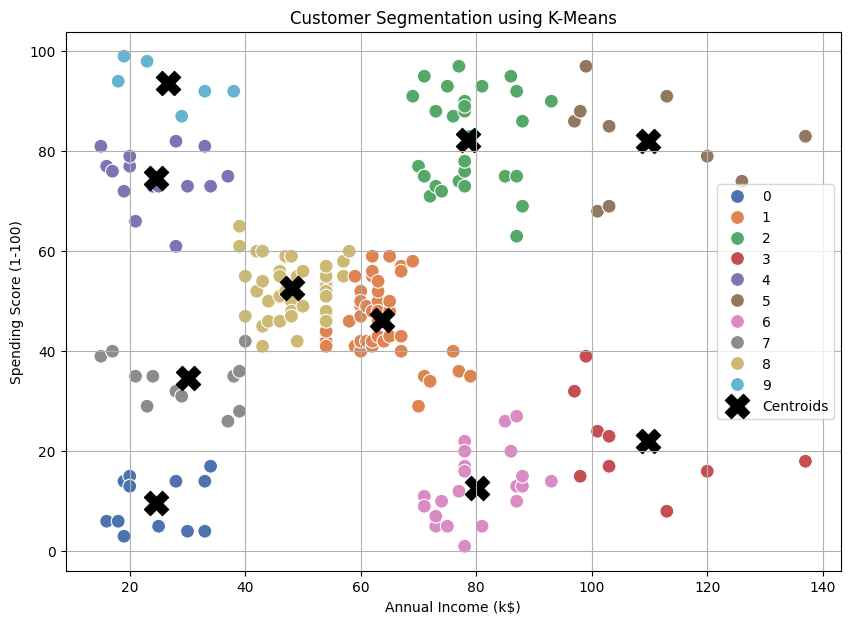

In [10]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='deep',
    s=100
)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
cluster_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).round(2)

print("Customer Segment Summary:")
display(cluster_summary)

Customer Segment Summary:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,48.75,24.58,9.58
1,41.67,63.72,46.16
2,32.86,78.55,82.17
3,41.00,109.70,22.00
4,24.93,24.47,74.60
5,32.20,109.70,82.00
6,41.00,80.18,12.68
7,39.62,30.00,34.62
8,43.98,48.10,52.68


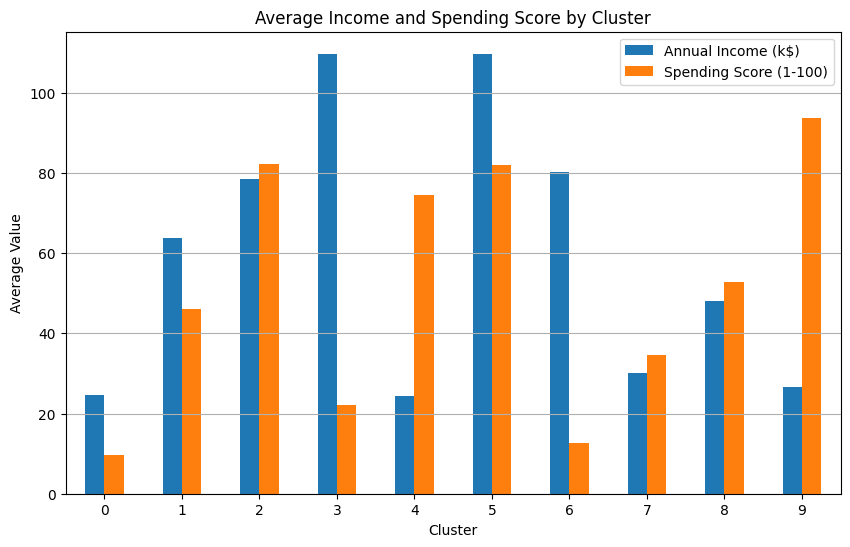

In [12]:
cluster_summary[['Annual Income (k$)', 'Spending Score (1-100)']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Average Income and Spending Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# **Conclusion:**
In this experiment, K-Means Clustering was successfully implemented to segment customers based on annual income and spending behavior. The Elbow Method and Silhouette Score were used to determine a suitable number of clusters. The customers were grouped into distinct segments with different income and spending characteristics. These segments can help businesses design targeted marketing campaigns, personalize customer offers, improve customer engagement, and support data-driven decision-making.

# **Questions & Answers :**
1. What is clustering? How does it differ from classification?

Clustering is an unsupervised machine learning technique that groups similar data points into clusters without using predefined labels.
Difference:

Clustering :
Unsupervised learning,
Uses unlabeled data,
Discovers groups automatically,
Example: customer segmentation.

Classification :
Supervised learning,
Uses labeled data,
Predicts predefined classes,
Example: spam/not-spam classification.

⸻

2. Explain the working principle of the K-Means Clustering algorithm.

K-Means works as follows:

1. Select the number of clusters K.
2. Initialize K cluster centroids.
3. Assign each data point to the nearest centroid based on distance.
4. Calculate the mean of points in each cluster.
5. Update the centroids using these means.
6. Repeat the assignment and centroid-update steps until the centroids become stable or the algorithm converges.

⸻

3. Why is feature scaling important before applying K-Means clustering?

K-Means uses distance calculations to assign data points to clusters. If features have different scales, a feature with larger numerical values may have a greater influence on the distance.

Feature scaling puts variables on a comparable scale, ensuring that each feature contributes appropriately to the clustering process.

⸻

4. What is the Elbow Method, and how does it help determine the optimal number of clusters?

The Elbow Method is used to find a suitable value of K.

It calculates the inertia for different numbers of clusters and plots K against inertia. As K increases, inertia decreases. The point where the decrease starts becoming less significant is called the elbow.

This point provides a reasonable choice for the number of clusters.

⸻

5. What is the Silhouette Score? How is it used to evaluate clustering performance?

The Silhouette Score measures how well each data point fits within its assigned cluster compared with other clusters.

Its value generally ranges from -1 to +1.

* Close to +1: Well-separated clusters
* Around 0: Overlapping clusters
* Below 0: Data points may be assigned to inappropriate clusters

A higher score generally indicates better-defined clustering.

⸻

6. Why is K-Means considered an unsupervised machine learning algorithm?

K-Means is considered unsupervised because it does not require predefined output labels or target classes.

It analyzes the input data and automatically discovers groups based on similarities between data points.

For example, in customer segmentation, we don’t tell the algorithm which customer belongs to which segment. K-Means identifies the groups automatically.

⸻

7. Mention any four real-world applications of customer segmentation.

Four applications are:

1. Targeted marketing — sending suitable offers to specific customer groups.
2. Personalized recommendations — recommending products based on customer behavior.
3. Customer retention — identifying groups that may need special engagement.
4. Product planning — understanding different customer preferences to improve products and services.

Other applications include pricing strategies, loyalty programs, and advertising campaigns.

⸻

8. What are the limitations of the K-Means algorithm?

Major limitations include:

1. The number of clusters K must be selected beforehand.
2. Results can be affected by the initial placement of centroids.
3. It can be sensitive to outliers.
4. It works best with roughly spherical and similarly sized clusters.
5. It may not perform well when clusters have complex or irregular shapes.
6. Different runs can sometimes produce different results depending on initialization.

⸻

9. How can businesses use customer segmentation to improve marketing and customer retention?

Businesses can divide customers into groups based on characteristics such as income, purchasing behavior, spending patterns, and demographics.

They can then:

* Create targeted marketing campaigns.
* Provide personalized discounts and offers.
* Recommend relevant products.
* Develop customer-specific loyalty programs.
* Identify customers who may require additional engagement.
* Improve customer satisfaction and retention.

This allows businesses to use their marketing resources more effectively.

⸻

10. Compare K-Means Clustering with Hierarchical Clustering based on their working principles and applications.

 K-Means Clustering and Hierarchical Clustering are both unsupervised machine learning techniques used to group similar data points. K-Means divides the data into a predefined number of clusters by assigning data points to the nearest centroid and repeatedly updating the centroids. In contrast, Hierarchical Clustering builds a hierarchy of clusters by either progressively merging smaller clusters or splitting larger clusters. K-Means is generally faster and suitable for large datasets, while Hierarchical Clustering is useful for smaller datasets where the relationships between different groups are important. K-Means is commonly used for customer segmentation, while Hierarchical Clustering can be used for customer grouping, document analysis, biological classification, and other applications where hierarchical relationships are useful.
